In [4]:
import utility_functions as utils
import GLM
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import numpy.matlib
sns.set_theme()

Simulate a toy system of two populations

# neuron1 -> neuron2 (only regress on neuron 2)

## One neuron

### Creating ground truth coupling filters and history filters

In [1131]:
nneuron = 1 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1132]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
# coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

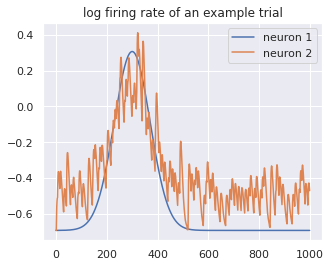

In [1133]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

### Fit GLM

In [1134]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=20, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

Negative log likelihood is: 157711.04
aic/2 is: 157731.04


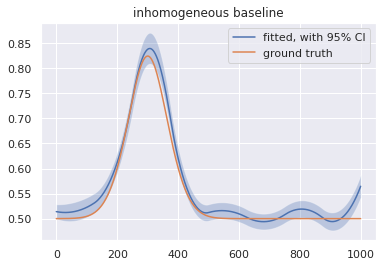

In [1135]:
GLM.plot_GLM_one_effect(model, effect_id=0, label='fitted, with 95% CI', 
                       title='inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]), label="ground truth")
plt.legend()

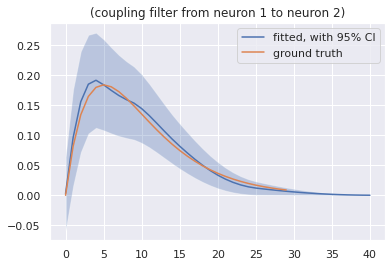

In [1136]:
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title='(coupling filter from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, label="ground truth")
plt.legend()


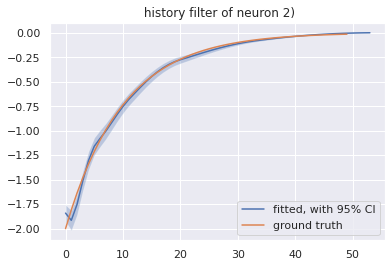

In [1137]:
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' history filter of neuron 2)')
plt.plot(ground_truth_history, label="ground truth")
plt.legend()


## Ten neurons

### Creating ground truth coupling filters and history filters

In [1421]:
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1422]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
# coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

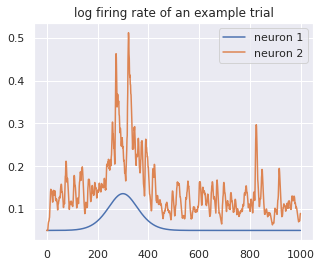

In [1423]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(np.exp(log_firing_rate_pop_level[0][:,itrial]), label='neuron 1')
plt.plot(np.exp(log_firing_rate_pop_level[1][:,itrial]), label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

In [1424]:
pop_spikes[1][500:,:].mean()

0.500872

### Fit GLM

In [1425]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=10, peaks_max=20, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=10, peaks_max=32, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

Negative log likelihood is: 426339.28
aic/2 is: 426369.28


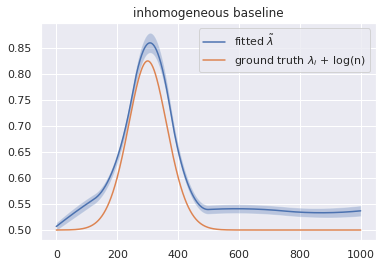

In [1426]:
GLM.plot_GLM_one_effect(model, effect_id=0, label=r'fitted $\tilde{\lambda}$ ', 
                        title=r'inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]+np.log(10)), label=r"ground truth $\lambda_i$ + log(n)")
plt.legend()

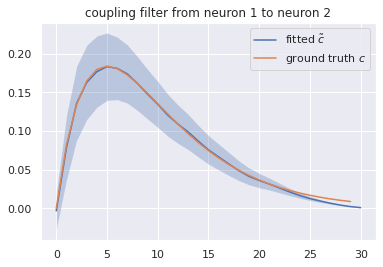

In [1427]:
GLM.plot_GLM_one_effect(model, effect_id=1, label=r'fitted $\tilde{c}$', 
                        title=r'coupling filter from neuron 1 to neuron 2')
plt.plot(ground_truth_coupling_filter, label=r"ground truth $c$")
plt.legend()

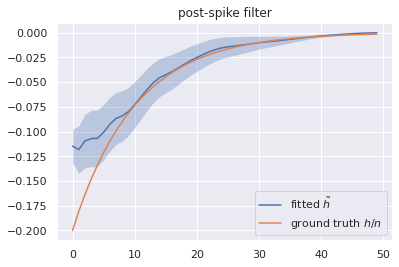

In [1428]:
GLM.plot_GLM_one_effect(model, effect_id=2, label=r'fitted $\tilde{h}$', 
                        title=r'post-spike filter')
plt.plot(ground_truth_history/nneuron, label=r"ground truth $h/n$")
plt.legend()

## Stablility dignostic

 p>=0.1:1.7185858585858587
 p>=0.1:1.7386868686868688
 p>=0.1:1.7386868686868688
 p>=0.1:1.7587878787878788
 p>=0.1:1.7587878787878788
 p>=0.1:1.778888888888889
 p>=0.1:1.778888888888889
 p>=0.1:1.778888888888889
 p>=0.1:1.778888888888889
 p>=0.1:1.7989898989898991
 p>=0.1:1.7989898989898991
 p>=0.1:1.7989898989898991
 p>=0.1:1.7989898989898991
 p>=0.1:1.7989898989898991
 p>=0.1:1.819090909090909
 p>=0.1:1.819090909090909
 p>=0.1:1.819090909090909
 p>=0.1:1.819090909090909
 p>=0.1:1.819090909090909
 p>=0.1:1.8391919191919193
 p>=0.1:1.8391919191919193
 p>=0.1:1.8391919191919193
 p>=0.1:1.8391919191919193
 p>=0.1:1.8391919191919193
 p>=0.1:1.8391919191919193
 p>=0.1:1.8391919191919193
 p>=0.1:1.8592929292929294
 p>=0.1:1.8592929292929294
 p>=0.1:1.8592929292929294
 p>=0.1:1.8592929292929294
 p>=0.1:1.8592929292929294
 p>=0.1:1.8592929292929294
 p>=0.1:1.8592929292929294
 p>=0.1:1.8592929292929294
 p>=0.1:1.8793939393939394
 p>=0.1:1.8793939393939394
 p>=0.1:1.8793939393939394
 p>=0.1:1.

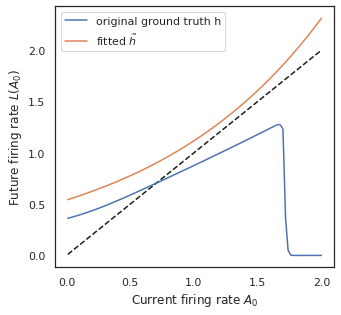

In [1447]:
def L_ind(A0, nneuron, c, h, beta0):
    A0_ind = A0/nneuron
    survive = 1
    meanISI = 0
    for i in range(len(h)):
        log_lambda = beta0
        log_lambda += (A0*c).sum()
        log_lambda += h[i]
        log_lambda += (A0_ind*h[i+1:]).sum()
        firing_rate = np.exp(log_lambda)
        p = survive*firing_rate
        if p>=0.5:
            print(f" p>=0.1:{A0}")
        survive -= p
        meanISI += p*(i+1)
    log_lambda = beta0
    log_lambda += (A0*c).sum()
    firing_rate = np.exp(log_lambda)

    while survive>1e-5:
        p = survive*firing_rate
        survive -= p
        meanISI += p*(i+1)
    return 10/meanISI
    
#     A0_ind = A0/nneuron
#     length = np.max((len(c), len(h)))
#     n_sample = 1000
#     sample = []
#     for i in range(n_sample):
#         y_ind = np.random.poisson(A0_ind, (length))
#         y = y_ind + np.random.poisson(A0-A0_ind, (length))
#         log_lambda = beta0
#         log_lambda += (y[-len(c):]*c).sum()
#         log_lambda += (y_ind[-len(h):]*h).sum()
#         sample.append(np.exp(log_lambda))
    
#     return nneuron*np.mean(sample)

# def L_pop(A0, nneuron, c, h, beta0):
#     ndt = 10
#     survive = 1
#     meanISI = 0
#     for i in range(len(h)):
#         for idt in range(ndt):
#             log_lambda = beta0
#             log_lambda += (A0*c).sum()
#             log_lambda += (A0*h).sum()
#             firing_rate = np.exp(log_lambda)
#             p = survive*firing_rate/ndt
#             survive -= p
#             meanISI += p*(i+1)
#     log_lambda = beta0
#     log_lambda += (A0*c).sum()
#     firing_rate = np.exp(log_lambda)
#     if p>=0.001:
#         print(" p>=0.001")
#     while survive>1e-5:
#         p = survive*firing_rate
#         survive -= p
#         meanISI += p*(i+1)
#     return 10/meanISI

################
def L_pop(A0, nneuron, c, h, beta0):
    length = np.max((len(c), len(h)))
    n_sample = 1000
    sample = []
    for i in range(n_sample):
        y = np.random.poisson(A0, (length))
        log_lambda = beta0
        log_lambda += (A0*c).sum()
        log_lambda += (A0*h).sum()
        sample.append(np.exp(log_lambda))
    
    return np.mean(sample)
#################

#     length = np.max((len(c), len(h)))
#     n_sample = 1000
#     sample = []
#     for i in range(n_sample):
#         y = np.random.poisson(A0, (length))
#         log_lambda = beta0
#         log_lambda += (y[-len(c):]*c).sum()
#         log_lambda += (y[-len(h):]*h).sum()
#         sample.append(np.exp(log_lambda))
    
#     return np.mean(sample)

A0_list = np.linspace(0.01, 2, 100)
LA0_ind = np.zeros_like(A0_list)
LA0_pop = np.zeros_like(A0_list)
for i, A0 in enumerate(A0_list):
    LA0_ind[i] = L_ind(A0, nneuron, ground_truth_coupling_filter, ground_truth_history, np.log(0.5/nneuron))
    LA0_pop[i] = L_pop(A0, nneuron, ground_truth_coupling_filter, model.get_filter()[2], np.log(0.54))
#     LA0_pop[i] = L_pop(A0, nneuron, ground_truth_coupling_filter, ground_truth_history/nneuron, np.log(0.55))

sns.set_style("white")
plt.subplots(figsize=(5,4.8))
plt.plot(A0_list, A0_list, 'k--')
plt.plot(A0_list, LA0_ind, label=r"original ground truth h")
plt.plot(A0_list, LA0_pop, label=r"fitted $\tilde{h}$")
plt.xlabel("Current firing rate $A_0$")
plt.ylabel("Future firing rate $L(A_0)$")
plt.legend()
sns.set_theme()

# neuron1 <--> neuron2 (regress both neuron and do simulation)

## One neuron

### Creating ground truth coupling filters and history filters

In [1138]:
nneuron = 1 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1139]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

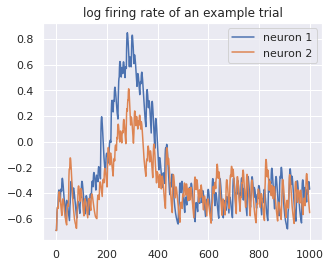

In [1140]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

### Fit GLM

In [1145]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=10, peaks_max=20, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=10, peaks_max=32, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

Negative log likelihood is: 158564.59
aic/2 is: 158594.59


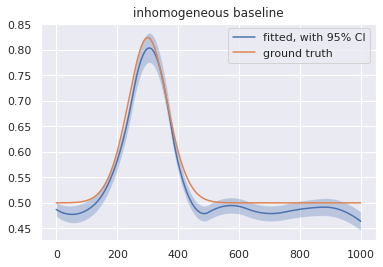

In [1146]:
GLM.plot_GLM_one_effect(model, effect_id=0, label='fitted, with 95% CI', 
                       title='inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]), label="ground truth")
plt.legend()

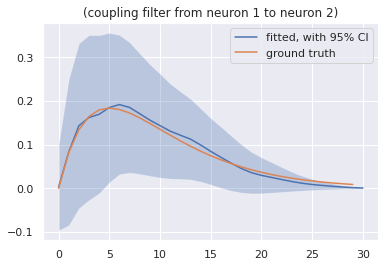

In [1147]:
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title='(coupling filter from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, label="ground truth")
plt.legend()


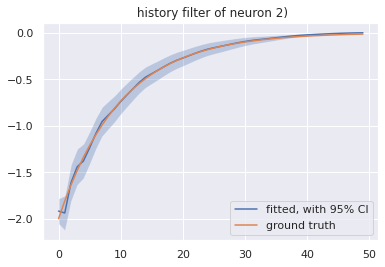

In [1148]:
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' history filter of neuron 2)')
plt.plot(ground_truth_history, label="ground truth")
plt.legend()


## Ten neurons

### Creating ground truth coupling filters and history filters

In [1272]:
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 100 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -3*np.exp(-time_line_history/10)/2

In [1273]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_ind_only_history = [np.zeros((nt, nneuron_list[ipop], ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial, log_firing_rate_ind_only_history_single_trial \
        = GLM.simulate_individual_history(baseline_mat, coupling_mat, history_list, 
                                          nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]
        log_firing_rate_ind_only_history[ipop][:, :, itrial] = log_firing_rate_ind_only_history_single_trial[ipop]

Text(0.5, 1.0, 'log firing rate of an example trial')

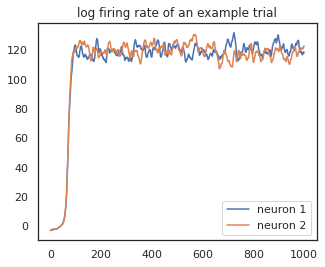

In [1274]:
itrial = 0
plt.subplots(figsize=(5,4))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

In [1271]:
pop_spikes[0][200:400,:].mean()

0.95805

### Fit GLM

In [1186]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=10, peaks_max=20, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=10, peaks_max=32, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

Negative log likelihood is: 88411.13
aic/2 is: 88441.13


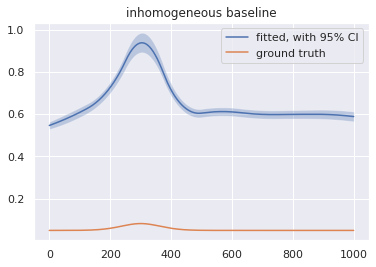

In [1187]:
GLM.plot_GLM_one_effect(model, effect_id=0, label='fitted, with 95% CI', 
                       title='inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]), label="ground truth")
plt.legend()

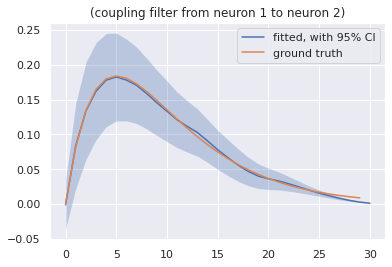

In [1172]:
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title='(coupling filter from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, label="ground truth")
plt.legend()


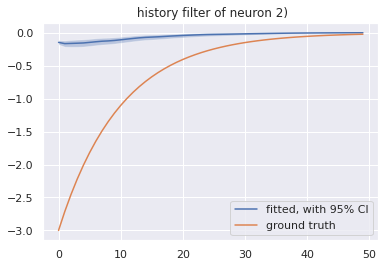

In [1173]:
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' history filter of neuron 2)')
plt.plot(ground_truth_history, label="ground truth")
plt.legend()
# plt.ylim([-3.5,0])
# plt.xlim([0,30])

# Reproducing explosion 

## Without considering history

In [1004]:
# Creating ground truth coupling filters and history filters
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [1005]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial = GLM.simulate_individual_history(baseline_mat, 
                                                                            coupling_mat, 
                                                                            history_list, 
                                                                            nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

ValueError: too many values to unpack (expected 2)

In [1006]:
model_list = []

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
# model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)
model_list.append(model)

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
# model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[0], verbose=True)
model_list.append(model)

Negative log likelihood is: 0.00
aic/2 is: 15.00
Negative log likelihood is: 0.00
aic/2 is: 15.00


In [1007]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((model_list[0].get_filter()[0], model_list[1].get_filter()[0])).T
coupling_mat = np.zeros((model_list[0].basis_list[1].shape[1], npop,npop))
coupling_mat[:,0,1] = np.flip(model_list[0].get_filter()[1].shape)
coupling_mat[:,1,0] = np.flip(model_list[1].get_filter()[1].shape)
# history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
# nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

## Considering history

In [748]:
# Creating ground truth coupling filters and history filters
nneuron = 10 # ten neurons in each population
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5/nneuron) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 

coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/10)

In [749]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial = GLM.simulate_individual_history(baseline_mat, 
                                                                            coupling_mat, 
                                                                            history_list, 
                                                                            nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

In [750]:
model_list = []

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)
model_list.append(model)

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[0], verbose=True)
model_list.append(model)

Negative log likelihood is: 28660.95
aic/2 is: 28680.95
Negative log likelihood is: 28672.15
aic/2 is: 28692.15


In [759]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((model_list[0].get_filter()[0], model_list[1].get_filter()[0])).T
coupling_mat = np.zeros((model_list[0].basis_list[1].shape[1], npop,npop))
coupling_mat[:,0,1] = np.flip(model_list[0].get_filter()[1].shape)
coupling_mat[:,1,0] = np.flip(model_list[1].get_filter()[1].shape)
history_list = [ model_list[i].get_filter()[2] for i in range(npop)] 
nneuron_list = [1]*npop

for itrial in range(ntrial):
    GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

ValueError: lam value too large

In [760]:
# Do simulation
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((model_list[0].get_filter()[0], model_list[1].get_filter()[0])).T
coupling_mat = np.zeros((model_list[0].basis_list[1].shape[1], npop,npop))
coupling_mat[:,0,1] = np.flip(model_list[0].get_filter()[1].shape)
coupling_mat[:,1,0] = np.flip(model_list[1].get_filter()[1].shape)
history_list = [ model_list[i].get_filter()[2] for i in range(npop)] 
nneuron_list = [1]*npop

temp = copy.deepcopy(history_list)
history_list = temp
max_histories_history = 0
if nneuron_list is not None:
    assert len(history_list) == len(nneuron_list), "The number of populations should matach!"
    for i, history in enumerate(history_list):
        assert history_list[i].ndim == 1
        history_list[i] = np.matlib.repmat(history, nneuron_list[i], 1).T
        max_histories_history = max(max_histories_history, history.shape[0])
else:
    for i, history in enumerate(history_list):
        nneuron_list[i] = history.shape[1]
        max_histories_history = max(max_histories_history, history.shape[0])

max_histories_coupling, _, npop = coupling_mat.shape
nt = baseline_mat.shape[0]
pop_spikes = np.zeros((nt, npop, 1))
ind_spikes = [np.zeros((nt, nneuron_list[i])) for i in range(npop)]
log_firing_rate_pop_level = copy.deepcopy(baseline_mat[:,:,np.newaxis])  # np.newaxis doesn't create a new data array!!!
# t=0
for ipop in range(npop):
    log_firing_rate_ind = log_firing_rate_pop_level[0, ipop, 0]*np.ones(nneuron_list[ipop]) \
                        - np.log(nneuron_list[i])
    log_firing_rate_ind_only_history = 0
    log_firing_rate_ind += log_firing_rate_ind_only_history
    ind_spikes[ipop][0, :] = np.random.poisson(np.exp(log_firing_rate_ind))
    pop_spikes[0,ipop,0] = np.sum(ind_spikes[ipop][0, :])

for t in range(1, nt):
    nhistories = min(t, max_histories_coupling)
    log_firing_rate_coupling = (coupling_mat[-nhistories:, :, :] * pop_spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
    log_firing_rate_pop_level[t,:,0] += log_firing_rate_coupling
    for ipop in range(npop):
        log_firing_rate_ind = log_firing_rate_pop_level[t, ipop, 0]*np.ones(nneuron_list[ipop]) \
                            - np.log(nneuron_list[ipop])
        nhistories = min(t, max_histories_history)
        log_firing_rate_ind_only_history = (history_list[ipop][-nhistories:,:] * ind_spikes[ipop][(t-nhistories):(t), :]).sum(axis=0)
        log_firing_rate_ind += log_firing_rate_ind_only_history
        ind_spikes[ipop][t, :] = np.random.poisson(np.exp(log_firing_rate_ind))
        pop_spikes[t,ipop,0] = np.sum(ind_spikes[ipop][t, :])

return pop_spikes.squeeze(), log_firing_rate_pop_level.squeeze()

/tmp/ipykernel_119447/1453145630.py:50: RuntimeWarning: overflow encountered in exp
  ind_spikes[ipop][t, :] = np.random.poisson(np.exp(log_firing_rate_ind))


ValueError: lam value too large

In [763]:
log_firing_rate_pop_level[:7,:,0]

array([[-1.20167810e+00, -1.22397221e+00],
       [-1.20016418e+00, -1.21991624e+00],
       [-1.19866357e+00, -1.21589196e+00],
       [-1.19717626e+00, -1.21189939e+00],
       [-1.19570225e+00, -1.20793852e+00],
       [ 3.98057585e+01,  3.97959906e+01],
       [ 7.85901587e+18,  7.93590807e+18]])

In [762]:
t

6